## Задача №2. Освоение наиболее популярных инструментов АВР, и обоснованный выбор методов статистических методов анализа ВР



### Импорты

In [29]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss

from statsforecast import StatsForecast
from statsforecast.models import ARIMA, AutoARIMA, AutoETS, AutoTheta
from prophet import Prophet

from pathlib import Path

PROJECT_DIR = Path.cwd()
PREPARED_DIR = PROJECT_DIR / 'prepared_data'

TS_PATH = PREPARED_DIR / 'eaf_final_temperature_series.csv'
FEATURES_PATH = PREPARED_DIR / 'eaf_temperature_heat_level_features.csv'

warnings.filterwarnings('ignore')


# Загрузка подготовленных данных

По итогам задачи 1 были сформированы исходящие файлы обработанного датасета

* **eaf_final_temperature_series.csv** - минимальный временной ряд в формате **unique_id**, **ds**, **target_time**, **y**;
* **eaf_temperature_heat_level_features.csv** - расширенная таблица признаков по плавкам для следующих ML/DL этапов.

In [30]:
ts_df = pd.read_csv(TS_PATH)
feature_df = pd.read_csv(FEATURES_PATH)

ts_df['target_time'] = pd.to_datetime(ts_df['target_time'])
ts_df['ds'] = ts_df['ds'].astype(int)
ts_df['y'] = ts_df['y'].astype(float)
ts_df = ts_df.sort_values('ds').reset_index(drop=True)

feature_df['target_time'] = pd.to_datetime(feature_df['target_time'])

FREQ = 'h'
ts_df['sf_ds'] = pd.date_range(start='2015-01-01', periods=len(ts_df), freq=FREQ)

sf_df = ts_df[['unique_id', 'sf_ds', 'y']].rename(columns={'sf_ds': 'ds'}).copy()
ds_lookup = ts_df[['sf_ds', 'target_time']].rename(columns={'sf_ds': 'ds'}).copy()

print('Размер ряда:', ts_df.shape)
print('Период реальных измерений:', ts_df['target_time'].min(), '—', ts_df['target_time'].max())
print('Число плавок:', ts_df['ds'].nunique())
print('Пропуски в y:', ts_df['y'].isna().sum())

sf_df.head()


Размер ряда: (20827, 5)
Период реальных измерений: 2015-01-01 01:32:00 — 2018-07-29 09:16:00
Число плавок: 20827
Пропуски в y: 0


,unique_id,ds,y
0,EAF_final_temperature,2015-01-01 00:00:00,1650.0
1,EAF_final_temperature,2015-01-01 01:00:00,1653.0
2,EAF_final_temperature,2015-01-01 02:00:00,1636.0
3,EAF_final_temperature,2015-01-01 03:00:00,1641.0
4,EAF_final_temperature,2015-01-01 04:00:00,1651.0


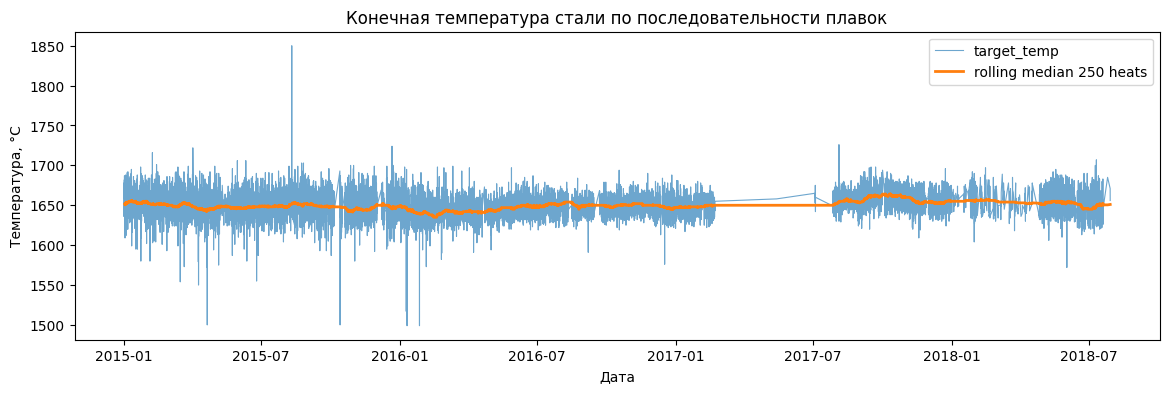

In [31]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts_df['target_time'], ts_df['y'], linewidth=0.8, alpha=0.65, label='target_temp')
ax.plot(ts_df['target_time'], ts_df['y'].rolling(250, min_periods=30).median(), linewidth=2, label='rolling median 250 heats')
ax.set_title('Конечная температура стали по последовательности плавок')
ax.set_xlabel('Дата')
ax.set_ylabel('Температура, °C')
ax.legend()
plt.show()


## Задача №2. Статистические методы прогнозирования

### Прогноз в statsforecast

Будем прогнозировать y = target_temp для следующих плавок. Горизонт H = 24 выбран как короткий производственный горизонт: примерно следующие 24 плавки.

В рамках задачи сравниваем статистические методы в двух режимах: ручной выбор структуры/параметров и автоматический подбор.

| семейство | ручной режим | автоматический режим |
|-----------|--------------|----------------------|
| ARIMA | ARIMA(order=(2, 1, 2)) | AutoARIMA |
| ETS | фиксированные структуры ANN, AAN | AutoETS(model='ZZZ') |
| Theta | фиксированный вариант STM`| AutoTheta(model=None) |
| Prophet | фиксированные changepoint_prior_scale и seasonality_prior_scale | подбор этих параметров по сетке на backtesting |

Для Prophet автоподбор Prophet реализуется явно: создаются несколько Prophet-конфигураций с разными гиперпараметрами, затем выбирается лучшая по MAE на бэктесте

In [32]:
H = 24
SEASON_LENGTH = 24
N_WINDOWS = 3
STEP_SIZE = 24
LEVELS = [80, 95]
CV_INPUT_SIZE = 3000
FIT_INPUT_SIZE = 3000

TEST_SIZE = H * N_WINDOWS
train_sf_df = sf_df.iloc[:-TEST_SIZE].copy()
test_sf_df = sf_df.iloc[-TEST_SIZE:].copy()
train_plot_df = ts_df.iloc[:-TEST_SIZE].copy()
test_plot_df = ts_df.iloc[-TEST_SIZE:].copy()

print('Горизонт прогноза H:', H)
print('Длина train:', len(train_sf_df))
print('Длина test:', len(test_sf_df))
print('Валидационных окон:', N_WINDOWS)
print('Размер хвоста для CV:', CV_INPUT_SIZE)
print('Размер хвоста для финального прогноза:', FIT_INPUT_SIZE)


Горизонт прогноза H: 24
Длина train: 20755
Длина test: 72
Валидационных окон: 3
Размер хвоста для CV: 3000
Размер хвоста для финального прогноза: 3000


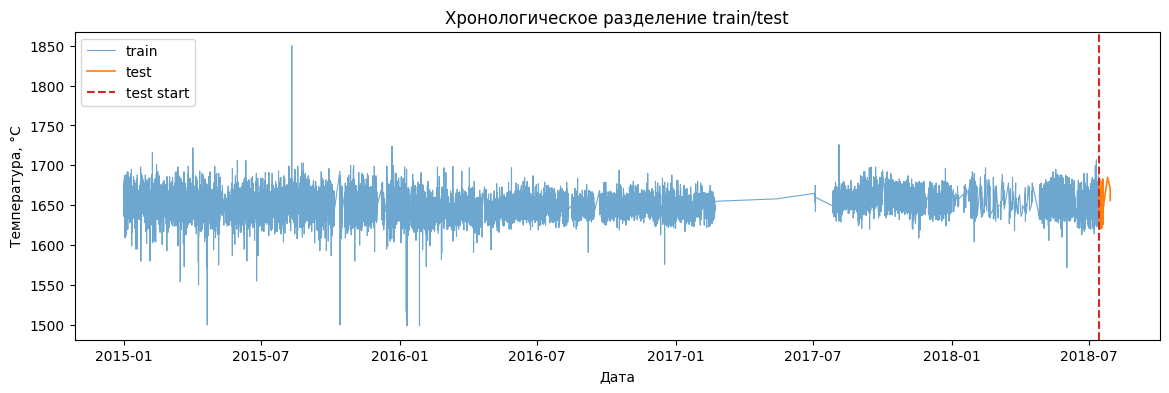

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_plot_df['target_time'], train_plot_df['y'], label='train', linewidth=0.8, alpha=0.65)
ax.plot(test_plot_df['target_time'], test_plot_df['y'], label='test', linewidth=1.2)
ax.axvline(test_plot_df['target_time'].min(), color='tab:red', linestyle='--', label='test start')
ax.set_title('Хронологическое разделение train/test')
ax.set_xlabel('Дата')
ax.set_ylabel('Температура, °C')
ax.legend()
plt.show()


### Метрики качества

Основная производственная интерпретация ошибки - градусы Цельсия. Поэтому главная метрика - MAE. Дополнительно считаем RMSE, MAPE и sMAPE.

In [33]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.abs(y_true - y_pred) / denominator) * 100


def get_model_columns(df):
    service_cols = {'unique_id', 'ds', 'cutoff', 'y', 'target_time'}
    return [
        c for c in df.columns
        if c not in service_cols and '-lo-' not in c and '-hi-' not in c
    ]


def evaluate_forecasts(eval_df, model_cols):
    rows = []
    for col in model_cols:
        data = eval_df[['y', col]].dropna()
        rows.append({
            'model': col,
            'MAE': mean_absolute_error(data['y'], data[col]),
            'RMSE': rmse(data['y'], data[col]),
            'MAPE_%': mape(data['y'], data[col]),
            'sMAPE_%': smape(data['y'], data[col]),
            'n_obs': len(data),
        })
    return pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)


## Диагностика ряда

Перед ARIMA-моделированием проверим стационарность и автокорреляционную структуру ряда. Результаты тестов используются как обоснование выбора ARIMA/AutoARIMA, но финальное сравнение моделей делаем по backtesting.

In [34]:
series = ts_df['y'].astype(float)
series_diff = series.diff().dropna()

adf_stat, adf_pvalue, *_ = adfuller(series)
kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')
adf_diff_stat, adf_diff_pvalue, *_ = adfuller(series_diff)
kpss_diff_stat, kpss_diff_pvalue, *_ = kpss(series_diff, regression='c', nlags='auto')

stationarity_table = pd.DataFrame({
    'series': ['target_temp', 'target_temp_diff_1'],
    'ADF_stat': [adf_stat, adf_diff_stat],
    'ADF_pvalue': [adf_pvalue, adf_diff_pvalue],
    'KPSS_stat': [kpss_stat, kpss_diff_stat],
    'KPSS_pvalue': [kpss_pvalue, kpss_diff_pvalue],
})

stationarity_table


,series,ADF_stat,ADF_pvalue,KPSS_stat,KPSS_pvalue
0,target_temp,-10.558973,7.817681e-19,7.554069,0.01
1,target_temp_diff_1,-34.655784,0.000000e+00,0.023480,0.10


Были применены два теста: ADF и KPSS.

Тест ADF проверяет нулевую гипотезу о наличии единичного корня (т.е. ряд “помнит” прошлые изменения и не возвращается к своему обычному уровню, т.е. например, если температура один раз случайно стала выше, то у стационарного ряда это отклонение со временем затухает: ряд возвращается примерно к своему среднему уровню.А если есть единичный корень, то случайный скачок как будто “прилипает” к ряду. Новый уровень становится новой нормой, и дальше ряд гуляет уже вокруг него.). 

То есть проверяем наличие признаков нестационарности ряда.

Для исходного ряда target_temp значение ADF_pvalue = 7,8 × 10⁻¹⁹, что значительно меньше 0.05. Значит, по ADF нулевая гипотеза отвергается, и ряд можно считать стационарным.

Однако тест KPSS проверяет противоположную гипотезу: его нулевая гипотеза состоит в том, что ряд стационарен. Для исходного ряда target_temp значение KPSS_pvalue = 0.01, что меньше 0.05. Значит, по KPSS гипотеза стационарности отвергается.

Таким образом, тесты дают противоречивый результат для исходного ряда: ADF указывает на стационарность, а KPSS — на нестационарность. Это может означать, что ряд не имеет выраженного единичного корня, но содержит структурные сдвиги, изменения уровня или трендовые участки. Такой вывод согласуется с EDA: конечная температура в целом стабильна, но в данных есть разрыв в 2017 году и небольшие сдвиги режима работы.

После первого дифференцирования **target_temp_diff_1** оба теста показывают стационарность:
- ADF_pvalue = 0.0, то есть ADF уверенно отвергает нестационарность;
- KPSS_pvalue = 0.10, то есть KPSS не отвергает стационарность.

Следовательно, для ARIMA-моделей оправдано рассматривать дифференцирование первого порядка, то есть параметр **d = 1**. Именно поэтому ручная модель **ARIMA(2,1,2)** выглядит обоснованной.

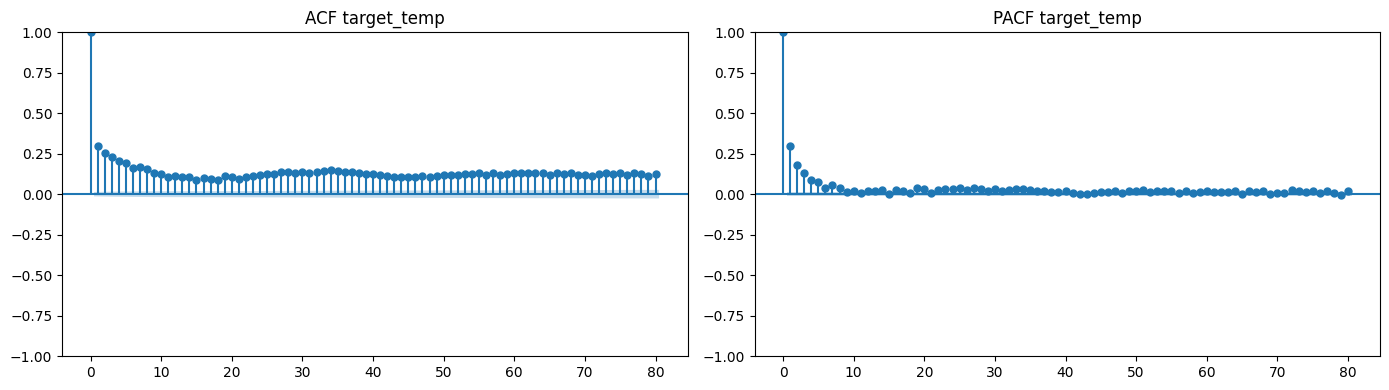

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series, lags=80, ax=axes[0])
axes[0].set_title('ACF target_temp')
plot_pacf(series, lags=80, ax=axes[1], method='ywm')
axes[1].set_title('PACF target_temp')
plt.tight_layout()
plt.show()


ACF показывает положительную автокорреляцию на первых лагах: соседние плавки связаны между собой, то есть температурный режим обладает инерцией. После первых лагов автокорреляция постепенно снижается, но остается положительной на большом числе лагов. Это говорит о том, что ряд не является полностью случайным шумом.

PACF имеет наиболее заметные значения на первых лагах, особенно на лаге 1, после чего частная автокорреляция быстро затухает и становится близкой к нулю. Это означает, что основная прямая зависимость текущей температуры объясняется несколькими ближайшими предыдущими плавками.

Такая структура ACF/PACF подтверждает целесообразность использования ARIMA. Наличие  зависимости на первых лагах говорит в пользу авторегрессионной части AR, а постепенное затухание ACF допускает использование компоненты MA . Поэтому ручная модель вида **ARIMA(2,1,2)** выглядит обоснованной для первичного сравнения со статистическими автоматическими моделями.

Таким образом: ряд имеет память ближайших плавок, но зависимость быстро ослабевает; это хороший аргумент в пользу ARIMA/AutoARIMA.

# Выбор моделей statsforecast

In [36]:
model_specs = []


def add_model(name, family, mode, description, model):
    model_specs.append({'name': name,
                        'family': family,
                        'mode': mode,
                        'description': description,
                        'model': model,})


add_model( name='ARIMA',
           family='ARIMA',
           mode='manual',
           description='Ручная ARIMA',
           model=ARIMA(order=(2, 1, 2), season_length=1, alias='ARIMA'),)

add_model( name='AutoARIMA',
           family='ARIMA',
           mode='auto',
           description='Автоматический подбор порядка ARIMA',
           model=AutoARIMA(season_length=1,
                           seasonal=False,
                           max_p=3,
                           max_q=3,
                           max_d=1,
                           max_order=5,
                           start_p=0,
                           start_q=0,
                           stepwise=True,
                           alias='AutoARIMA'),)

add_model( name='ETS_manual_ANN',
           family='ETS',
           mode='manual',
           description='Ручной ETS без тренда и сезонности: additive error, no trend, no seasonality',
           model=AutoETS(season_length=SEASON_LENGTH, model='ANN', alias='ETS_manual_ANN'),)

add_model( name='ETS_manual_AAN',
           family='ETS',
           mode='manual',
           description='Ручной ETS с аддитивным трендом без сезонности: additive error, additive trend, no seasonality',
           model=AutoETS(season_length=SEASON_LENGTH, model='AAN', damped=False, alias='ETS_manual_AAN'),)

add_model( name='AutoETS',
           family='ETS',
           mode='auto',
           description='Автоматический выбор ETS-структуры',
           model=AutoETS(season_length=SEASON_LENGTH, model='ZZZ', alias='AutoETS'),)

add_model( name='Theta_manual_STM',
           family='Theta',
           mode='manual',
           description='Ручной выбор стандартной Theta-модели STM',
           model=AutoTheta(season_length=SEASON_LENGTH,
                           decomposition_type='additive',
                           model='STM',
                           alias='Theta_manual_STM'),)

add_model( name='AutoTheta',
           family='Theta',
           mode='auto',
           description='Автоматический выбор Theta-варианта: STM, OTM, DSTM или DOTM',
           model=AutoTheta(season_length=SEASON_LENGTH,
                           decomposition_type='additive',
                           model=None,
                           alias='AutoTheta'),)

models = [spec['model'] for spec in model_specs]
model_metadata = pd.DataFrame([{key: value for key, value in spec.items() if key != 'model'} for spec in model_specs])

model_metadata


,name,family,mode,description
0,ARIMA,ARIMA,manual,Ручная ARIMA
1,AutoARIMA,ARIMA,auto,Автоматический подбор порядка ARIMA
2,ETS_manual_ANN,ETS,manual,Ручной ETS без тренда и сезонности: additive e...
3,ETS_manual_AAN,ETS,manual,Ручной ETS с аддитивным трендом без сезонности...
4,AutoETS,ETS,auto,Автоматический выбор ETS-структуры
5,Theta_manual_STM,Theta,manual,Ручной выбор стандартной Theta-модели STM
6,AutoTheta,Theta,auto,"Автоматический выбор Theta-варианта: STM, OTM,..."


## Backtesting моделей

Используем rolling-origin backtesting через **StatsForecast.cross_validation**. 

In [ ]:
sf = StatsForecast(models=models, freq=FREQ, n_jobs=-1)

cv_df = sf.cross_validation( df=sf_df,
                             h=H,
                             n_windows=N_WINDOWS,
                             step_size=STEP_SIZE,
                             input_size=CV_INPUT_SIZE,
                             refit=True,
                             level=LEVELS,)

cv_df = cv_df.merge(ds_lookup, on='ds', how='left')
model_cols = get_model_columns(cv_df)
metrics_sf = evaluate_forecasts(cv_df, model_cols)
metrics_sf = metrics_sf.merge( model_metadata,
                               how='left',
                               left_on='model',
                               right_on='name',).drop(columns=['name'])

metrics_report = metrics_sf.sort_values('MAE').reset_index(drop=True)
metrics_report


,model,MAE,RMSE,MAPE_%,sMAPE_%,n_obs,family,mode,description
0,ARIMA,13.856497,16.764649,0.839273,0.839048,72,ARIMA,manual,Ручная ARIMA
1,AutoARIMA,13.868030,16.740196,0.839903,0.839748,72,ARIMA,auto,Автоматический подбор порядка ARIMA
2,AutoTheta,14.450293,17.007240,0.874892,0.875013,72,Theta,auto,"Автоматический выбор Theta-варианта: STM, OTM,..."
3,ETS_manual_ANN,14.454859,17.009557,0.875201,0.875289,72,ETS,manual,Ручной ETS без тренда и сезонности: additive e...
4,AutoETS,14.454859,17.009557,0.875201,0.875289,72,ETS,auto,Автоматический выбор ETS-структуры
5,Theta_manual_STM,14.455281,17.009568,0.875210,0.875315,72,Theta,manual,Ручной выбор стандартной Theta-модели STM
6,ETS_manual_AAN,14.472237,17.020004,0.876255,0.876343,72,ETS,manual,Ручной ETS с аддитивным трендом без сезонности...


По результатам rolling-origin backtesting лучшей моделью оказалась **ручная ARIMA(2,1,2)**:

MAE = 13.86 °C, RMSE = 16.76 °C.

Очень близкий результат показала **AutoARIMA**:

MAE = 13.87 °C, RMSE = 16.74 °C.

Разница минимальна. Это означает, что выбранная вручную структура ARIMA хорошо согласуется с автоматическим подбором модели. Также это подтверждает выводы диагностики ряда: после первого дифференцирования ряд становится стационарным, а зависимость на первых лагах хорошо описывается ARIMA-подходом.

Модели **ETS** и **Theta** псовсем немного слабее. 

Их MAE находится примерно в диапазоне 14.45-14.47 °C, то есть ошибка выше примерно на 0.6 °C по сравнению с ARIMA. Разница не критическая, но стабильная: ARIMA-модели чуть лучше учитывают авторегрессионную структуру ряда конечной температуры.

**AutoETS** дал такой же результат, как **ETS_manual_ANN**`**. Это означает, что автоматический подбор ETS фактически выбрал простую структуру без тренда и сезонности. Такой результат согласуется с EDA: выраженной сезонности у ряда конечной температуры не обнаружено.

**AutoTheta**`** и **Theta_manual_STM** также дали почти одинаковые результаты. Это говорит о том, что автоматический подбор Theta не нашел существенно более сильной конфигурации по сравнению со стандартной Theta-моделью.

В целом статистические модели дают ошибку порядка **14 °C**. Это можно использовать как benchmark для следующих этапов: ML/DL модели должны показать качество лучше.

## Prophet 

Использую пакет prophet с TSPprohpet у меня что-то не заладилось.

В этом блоке добавлю к общему сравнению:

* **Prophet_manual** - фиксированная ручная конфигурация;
* **Prophet_auto_** - набор кандидатов для автоподбора changepoint_prior_scale и seasonality_prior_scale по backtesting.

После расчета Prophet-метрики объединяются с таблицей **metrics_report**, чтобы лучшая модель выбиралась из всех статистических подходов.


In [38]:
def make_prophet_model(params, interval_width=0.95):
    model = Prophet( growth='linear',
                     seasonality_mode='additive',
                     changepoint_prior_scale=params['changepoint_prior_scale'],
                     seasonality_prior_scale=params['seasonality_prior_scale'],
                     daily_seasonality=True,
                     weekly_seasonality=False,
                     yearly_seasonality=False,
                     interval_width=interval_width, )
    return model


def prophet_rolling_backtest( input_df, configs, 
                              h=H, n_windows=N_WINDOWS, 
                              step_size=STEP_SIZE, 
                              input_size=CV_INPUT_SIZE):
    n = len(input_df)
    first_cutoff = n - h - step_size * (n_windows - 1)
    cutoffs = [first_cutoff + i * step_size for i in range(n_windows)]
    fold_frames = []

    for cutoff in cutoffs:
        train_start = max(0, cutoff - input_size)
        train_part = input_df.iloc[train_start:cutoff][['ds', 'y']].copy()
        test_part = input_df.iloc[cutoff:cutoff + h][['unique_id', 'ds', 'y']].copy()
        test_part['cutoff'] = input_df.iloc[cutoff - 1]['ds']

        fold = test_part.copy()
        for config in configs:
            model = make_prophet_model(config['params'])
            model.fit(train_part)
            forecast = model.predict(test_part[['ds']])
            fold[config['name']] = forecast['yhat'].to_numpy()
            fold[f"{config['name']}-lo-95"] = forecast['yhat_lower'].to_numpy()
            fold[f"{config['name']}-hi-95"] = forecast['yhat_upper'].to_numpy()

        fold_frames.append(fold)

    return pd.concat(fold_frames, ignore_index=True)


prophet_configs = [
    {
        'name': 'Prophet_manual',
        'family': 'Prophet',
        'mode': 'manual',
        'description': 'Ручная Prophet-конфигурация с фиксированными prior-параметрами',
        'params': {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1},
    },
    {
        'name': 'Prophet_auto_cps0p001_sps0p1',
        'family': 'Prophet',
        'mode': 'auto_candidate',
        'description': 'Prophet-кандидат для автоподбора: cps=0.001, sps=0.1',
        'params': {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.1},
    },
    {
        'name': 'Prophet_auto_cps0p01_sps0p1',
        'family': 'Prophet',
        'mode': 'auto_candidate',
        'description': 'Prophet-кандидат для автоподбора: cps=0.01, sps=0.1',
        'params': {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1},
    },
    {
        'name': 'Prophet_auto_cps0p05_sps0p1',
        'family': 'Prophet',
        'mode': 'auto_candidate',
        'description': 'Prophet-кандидат для автоподбора: cps=0.05, sps=0.1',
        'params': {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 0.1},
    },
    {
        'name': 'Prophet_auto_cps0p01_sps1p0',
        'family': 'Prophet',
        'mode': 'auto_candidate',
        'description': 'Prophet-кандидат для автоподбора: cps=0.01, sps=1.0',
        'params': {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0},
    },
]

prophet_cv = prophet_rolling_backtest(sf_df, prophet_configs)
prophet_cv = prophet_cv.merge(ds_lookup, on='ds', how='left')
prophet_model_cols = get_model_columns(prophet_cv)
prophet_metadata = pd.DataFrame([{key: value for key, value in config.items() if key != 'params'} for config in prophet_configs])

prophet_metrics = evaluate_forecasts(prophet_cv, prophet_model_cols).merge(
    prophet_metadata,
    how='left',
    left_on='model',
    right_on='name',).drop(columns=['name'])

merge_keys = ['unique_id', 'ds', 'cutoff', 'y', 'target_time']
prophet_value_cols = [c for c in prophet_cv.columns if c not in merge_keys]
cv_df = cv_df.merge(prophet_cv[merge_keys + prophet_value_cols], on=merge_keys, how='outer')

all_metrics = pd.concat([metrics_sf, prophet_metrics], ignore_index=True).sort_values('MAE').reset_index(drop=True)

prophet_auto_candidates = prophet_metadata.loc[prophet_metadata['mode'] == 'auto_candidate', 'name'].tolist()
best_prophet_auto = all_metrics[all_metrics['model'].isin(prophet_auto_candidates)].head(1).copy()
non_auto_prophet = all_metrics[~all_metrics['model'].isin(prophet_auto_candidates)].copy()

if len(best_prophet_auto):
    best_candidate_name = best_prophet_auto.iloc[0]['model']
    best_prophet_auto.loc[:, 'description'] = 'Лучший Prophet-кандидат по backtesting: ' + best_candidate_name
    best_prophet_auto.loc[:, 'model'] = 'Prophet_auto_best'
    best_prophet_auto.loc[:, 'mode'] = 'auto'
    metrics_report = pd.concat([non_auto_prophet, best_prophet_auto], ignore_index=True).sort_values('MAE').reset_index(drop=True)
else:
    metrics_report = all_metrics.copy()

metrics_report


16:53:37 - cmdstanpy - INFO - Chain [1] start processing
16:53:37 - cmdstanpy - INFO - Chain [1] done processing
16:53:38 - cmdstanpy - INFO - Chain [1] start processing
16:53:38 - cmdstanpy - INFO - Chain [1] done processing
16:53:38 - cmdstanpy - INFO - Chain [1] start processing
16:53:38 - cmdstanpy - INFO - Chain [1] done processing
16:53:39 - cmdstanpy - INFO - Chain [1] start processing
16:53:39 - cmdstanpy - INFO - Chain [1] done processing
16:53:40 - cmdstanpy - INFO - Chain [1] start processing
16:53:40 - cmdstanpy - INFO - Chain [1] done processing
16:53:40 - cmdstanpy - INFO - Chain [1] start processing
16:53:41 - cmdstanpy - INFO - Chain [1] done processing
16:53:41 - cmdstanpy - INFO - Chain [1] start processing
16:53:41 - cmdstanpy - INFO - Chain [1] done processing
16:53:41 - cmdstanpy - INFO - Chain [1] start processing
16:53:42 - cmdstanpy - INFO - Chain [1] done processing
16:53:42 - cmdstanpy - INFO - Chain [1] start processing
16:53:42 - cmdstanpy - INFO - Chain [1]

,model,MAE,RMSE,MAPE_%,sMAPE_%,n_obs,family,mode,description
0,ARIMA,13.856497,16.764649,0.839273,0.839048,72,ARIMA,manual,Ручная ARIMA
1,AutoARIMA,13.868030,16.740196,0.839903,0.839748,72,ARIMA,auto,Автоматический подбор порядка ARIMA
2,Prophet_auto_best,14.229744,17.209064,0.860822,0.861638,72,Prophet,auto,Лучший Prophet-кандидат по backtesting: Prophe...
3,Prophet_manual,14.445379,17.385004,0.873227,0.874717,72,Prophet,manual,Ручная Prophet-конфигурация с фиксированными p...
4,AutoTheta,14.450293,17.007240,0.874892,0.875013,72,Theta,auto,"Автоматический выбор Theta-варианта: STM, OTM,..."
5,ETS_manual_ANN,14.454859,17.009557,0.875201,0.875289,72,ETS,manual,Ручной ETS без тренда и сезонности: additive e...
6,AutoETS,14.454859,17.009557,0.875201,0.875289,72,ETS,auto,Автоматический выбор ETS-структуры
7,Theta_manual_STM,14.455281,17.009568,0.875210,0.875315,72,Theta,manual,Ручной выбор стандартной Theta-модели STM
8,ETS_manual_AAN,14.472237,17.020004,0.876255,0.876343,72,ETS,manual,Ручной ETS с аддитивным трендом без сезонности...


Лучшим Prophet-вариантом стал **Prophet_auto_best**:

MAE = 14.23 °C, RMSE = 17.21 °C.

Он оказался чуть-чуть лучше ручной конфигурации Prophet_manual:

MAE = 14.45 °C, RMSE = 17.39 °C.

Это означает, что подбор гиперпараметров `changepoint_prior_scale` и `seasonality_prior_scale` немного улучшил качество модели Prophet. Автоматически подобранная конфигурация немного лучше адаптировалась к уровню сглаживания тренда и сезонной компоненты.

При этом Prophet все равно уступил ARIMA-моделям. У лучшей ARIMA:

MAE = 13.86 °C.

У лучшего Prophet:

MAE = 14.23 °C.

Разница составляет примерно 0.37 °C по MAE. Вероятно, для данного ряда важнее краткосрочная авторегрессионная зависимость между соседними плавками, чем трендовая структура, которую моделирует Prophet.

В то же время **Prophet_auto_best** оказался лучше ETS и Theta-моделей, у которых MAE около 14.45 °C. Значит, Prophet полезен для сравнения и дает конкурентное качество, но в текущей постановке не является лучшей моделью.

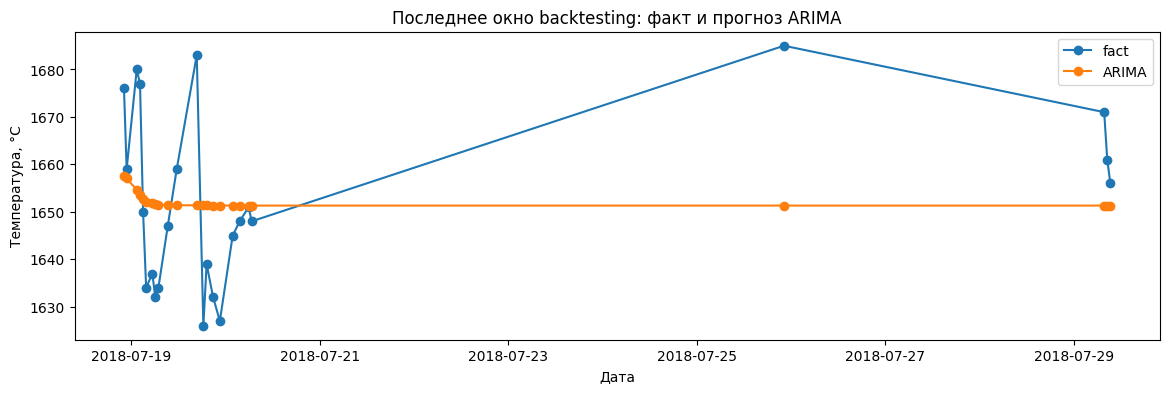

In [40]:
best_model = metrics_report.iloc[0]['model']
last_cutoff = cv_df['cutoff'].max()
plot_df = cv_df[cv_df['cutoff'] == last_cutoff].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_df['target_time'], plot_df['y'], marker='o', label='fact')
ax.plot(plot_df['target_time'], plot_df[best_model], marker='o', label=best_model)
ax.set_title(f'Последнее окно backtesting: факт и прогноз {best_model}')
ax.set_xlabel('Дата')
ax.set_ylabel('Температура, °C')
ax.legend()
plt.show()


На последнем окне backtesting фактическая конечная температура заметно колеблется: значения меняются примерно от 1625 до 1685 °C. При этом прогноз лучшей модели почти горизонтальный и находится около 1651-1652 °C.

Такое поведение означает, что модель хорошо улавливает средний уровень ряда, но плохо воспроизводит краткосрочные скачки температуры между отдельными плавками. Она фактически дает сглаженный прогноз около типичного значения конечной температуры.

Это объяснимо для статистической модели без технологических признаков: она видит только историю целевой температуры и не знает, какие были режимы трансформатора, загрузка, кислород, углерод или добавки в конкретной будущей плавке.

Таким образом  модель предсказывает средний уровень температуры, но не ловит резкие отклонения отдельных плавок.

Следовательно, статистический прогноз полезен как базовый benchmark, но для более точного прогноза отдельных плавок попробуем использовать расширенную таблицу признаков и ML/DL-модели.

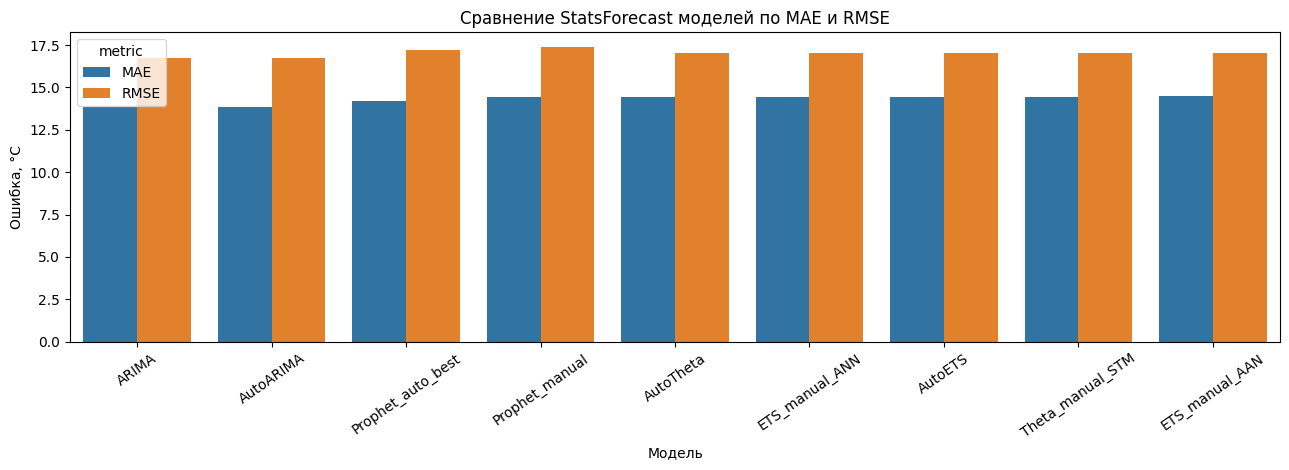

In [42]:
metrics_long = metrics_report.melt(
    id_vars=['model', 'family', 'mode', 'n_obs'],
    value_vars=['MAE', 'RMSE', 'MAPE_%', 'sMAPE_%'],
    var_name='metric',
    value_name='value',)

fig, ax = plt.subplots(figsize=(13, 4.8))
sns.barplot(
    data=metrics_long[metrics_long['metric'].isin(['MAE', 'RMSE'])],
    x='model',
    y='value',
    hue='metric',
    ax=ax,)

ax.set_title('Сравнение StatsForecast моделей по MAE и RMSE')
ax.set_xlabel('Модель')
ax.set_ylabel('Ошибка, °C')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


По графику видно, что минимальные значения **MAE** и **RMSE** показывают модели семейства ARIMA. Лучшей по **MAE** является ручная **ARIMA**, а **AutoARIMA** дает почти такой же результат.

**Prophet_auto_best** занимает промежуточное положение: он хуже ARIMA, но лучше ручного Prophet, ETS и Theta. Это подтверждает, что автоподбор параметров Prophet немного улучшает качество прогноза.

ETS и Theta показывают очень близкие результаты между собой, но немного уступают ARIMA и лучшему Prophet. В целом различия между статистическими моделямималенькие, но ARIMA выбираем как бенчмарк для следующих этапов.

## Прогноз на следующий горизонт

После сравнения моделей строим прогноз на следующие **H** плавок по всей доступной истории. Этот прогноз нужен как пример работы статистической модели после выбора подхода.

In [43]:
import copy

forecast_train_df = sf_df.tail(FIT_INPUT_SIZE).copy()
forecast_df = pd.DataFrame()

if best_model in model_metadata['name'].values:
    best_spec = next(spec for spec in model_specs if spec['name'] == best_model)
    best_model_object = copy.deepcopy(best_spec['model'])
    sf_final = StatsForecast(models=[best_model_object], freq=FREQ, n_jobs=1)
    forecast_df = sf_final.forecast(df=forecast_train_df, h=H, level=LEVELS)
elif best_model.startswith('Prophet'):
    if best_model == 'Prophet_auto_best':
        best_candidate = metrics_report.loc[metrics_report['model'] == 'Prophet_auto_best', 'description'].iloc[0].split(': ')[-1]
        best_config = next(config for config in prophet_configs if config['name'] == best_candidate)
    else:
        best_config = next(config for config in prophet_configs if config['name'] == best_model)

    prophet_model = make_prophet_model(best_config['params'])
    prophet_model.fit(forecast_train_df[['ds', 'y']])
    future = pd.DataFrame({
        'ds': pd.date_range(
            start=forecast_train_df['ds'].max(),
            periods=H + 1,
            freq=FREQ,
        )[1:]
    })
    
    prophet_forecast = prophet_model.predict(future)
    forecast_df = pd.DataFrame({
        'unique_id': forecast_train_df['unique_id'].iloc[-1],
        'ds': future['ds'],
        best_model: prophet_forecast['yhat'].to_numpy(),
        f'{best_model}-lo-95': prophet_forecast['yhat_lower'].to_numpy(),
        f'{best_model}-hi-95': prophet_forecast['yhat_upper'].to_numpy(),
    })
else:
    raise ValueError(f'Не удалось найти объект лучшей модели: {best_model}')

forecast_model_cols = get_model_columns(forecast_df)
forecast_df.head()


,unique_id,ds,ARIMA,ARIMA-lo-95,ARIMA-lo-80,ARIMA-hi-80,ARIMA-hi-95
0,EAF_final_temperature,2017-05-17 19:00:00,1654.208678,1629.802388,1638.250263,1670.167093,1678.614968
1,EAF_final_temperature,2017-05-17 20:00:00,1652.799010,1627.902300,1636.519926,1669.078094,1677.695720
2,EAF_final_temperature,2017-05-17 21:00:00,1652.043366,1626.719066,1635.484696,1668.602035,1677.367665
3,EAF_final_temperature,2017-05-17 22:00:00,1651.592276,1626.142606,1634.951631,1668.232920,1677.041945
4,EAF_final_temperature,2017-05-17 23:00:00,1651.331788,1625.829515,1634.656748,1668.006827,1676.834060


Лучшая модель **ARIMA** построила прогноз на следующие плавки. Прогнозируемая конечная температура находится в узком диапазоне около 1651-1654 °C.

На первых шагах прогноза видно небольшое снижение:

- первый шаг: около 1654.2 °C;
- пятый шаг: около 1651.3 °C.

Далее модель, вероятно, будет стремиться к среднему устойчивому уровню ряда: модель не прогнозирует резкие скачки, а сглаживает будущие значения около ожидаемого уровня.

Интервалы предсказания достаточно широкие. Для первых прогнозных шагов 95%-интервал примерно находится в диапазоне:

**1626-1678 °C**.

Это означает, что точечный прогноз можно использовать как ориентир среднего ожидаемого уровня, но для отдельных плавок возможны существенные отклонения. Такие отклонения связаны с тем, что статистическая модель использует только историю конечной температуры и не учитывает технологические параметры будущей плавки.

Следовательно, прогноз ARIMA полезен как базовый статистический ориентир, но для более точного прогноза конкретной плавки необходимо использовать технологические признаки и ML/DL-модели.

ARIMA прогнозирует стабильный уровень около 1651-1654 °C, но интервалы показывают, что неопределенность для отдельных плавок остается заметной.

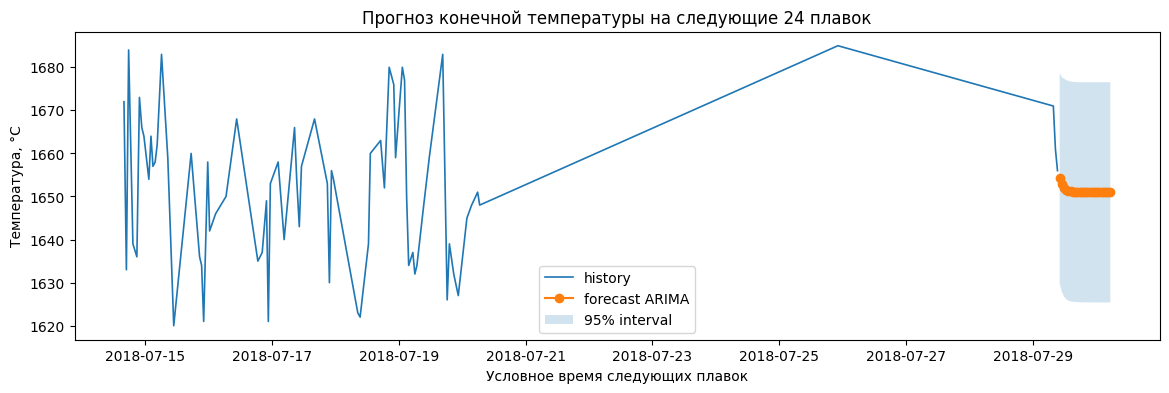

In [44]:
history_tail = sf_df.tail(SEASON_LENGTH * 3).merge(ds_lookup, on='ds', how='left')
forecast_plot_df = forecast_df.copy()
forecast_plot_df['target_time'] = pd.date_range(
    start=ts_df['target_time'].max(),
    periods=H + 1,
    freq='50min',
)[1:]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(history_tail['target_time'], history_tail['y'], label='history', linewidth=1.2)
ax.plot(forecast_plot_df['target_time'], forecast_plot_df[best_model], marker='o', label=f'forecast {best_model}')

lo_col = f'{best_model}-lo-95'
hi_col = f'{best_model}-hi-95'
if lo_col in forecast_plot_df.columns and hi_col in forecast_plot_df.columns:
    ax.fill_between(forecast_plot_df['target_time'], forecast_plot_df[lo_col], forecast_plot_df[hi_col], alpha=0.2, label='95% interval')

ax.set_title(f'Прогноз конечной температуры на следующие {H} плавок')
ax.set_xlabel('Условное время следующих плавок')
ax.set_ylabel('Температура, °C')
ax.legend()
plt.show()


## Диагностика остатков лучшей модели

Проверим остатки лучшей модели по backtesting. Если в остатках сохраняется автокорреляция, значит модель не полностью использовала временную структуру ряда.

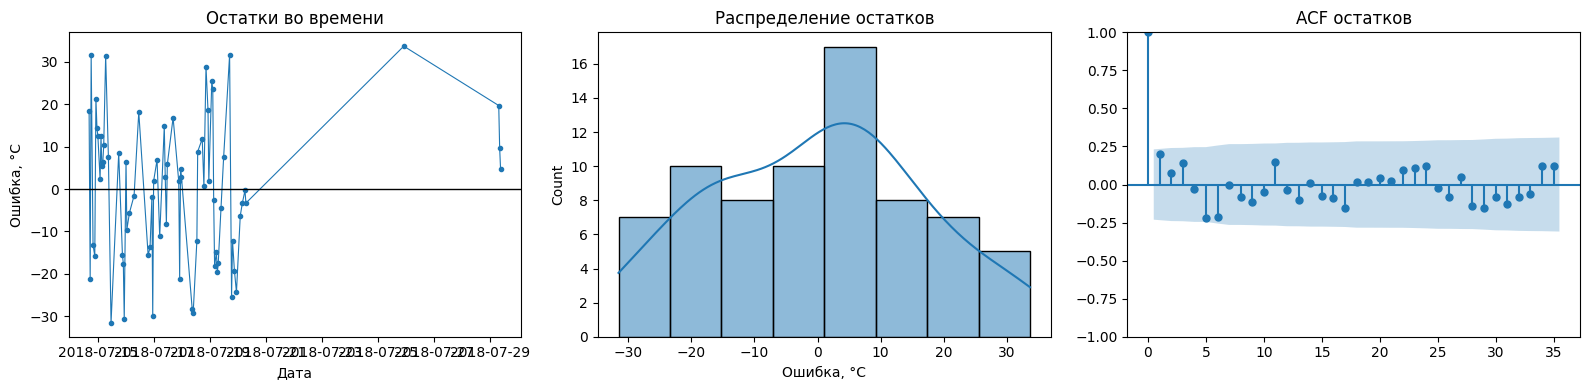

best_model: ARIMA
Jarque-Bera p-value: 0.42990804612958167


,lb_stat,lb_pvalue
1,2.977976,0.084405
5,8.940619,0.111456
10,14.447994,0.153520
24,25.262545,0.391608


In [45]:
residuals_df = cv_df[['ds', 'target_time', 'y', 'cutoff', best_model]].dropna().copy()
residuals_df['residual'] = residuals_df['y'] - residuals_df[best_model]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(residuals_df['target_time'], residuals_df['residual'], marker='.', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Остатки во времени')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Ошибка, °C')

sns.histplot(residuals_df['residual'], kde=True, ax=axes[1])
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Ошибка, °C')

plot_acf(residuals_df['residual'], lags=min(60, len(residuals_df) // 2 - 1), ax=axes[2])
axes[2].set_title('ACF остатков')

plt.tight_layout()
plt.show()

ljung_box = acorr_ljungbox(residuals_df['residual'], lags=[1, 5, 10, 24], return_df=True)
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals_df['residual'])

print('best_model:', best_model)
print('Jarque-Bera p-value:', jb_pvalue)
display(ljung_box)


По диагностике остатков видно, что ошибки модели колеблются вокруг нуля, без выраженного устойчивого смещения вверх или вниз. Это означает, что модель в среднем не завышает и не занижает прогноз систематически.

Распределение остатков близко к симметричному, но есть отдельные крупные ошибки примерно до ±30 °C. Это говорит о том, что модель хорошо описывает средний уровень температуры, но не всегда улавливает резкие отклонения отдельных плавок.

ACF остатков в основном находится внутри доверительных границ. Значит, выраженной автокорреляции в ошибках не осталось, и ARIMA достаточно хорошо использовала временную структуру ряда.

Для лучшей модели `ARIMA` дополнительно были рассчитаны статистические тесты по остаткам.

Тест Jarque-Bera дал p-value = 0.43, что больше 0.05. Следовательно, нет оснований отвергать гипотезу о нормальности распределения остатков. Это согласуется с гистограммой: распределение ошибок в целом выглядит достаточно симметричным, хотя отдельные крупные ошибки присутствуют.

Тест Ljung-Box был рассчитан на лагах 1, 5, 10 и 24. Во всех случаях p-value > 0.05:

- лаг 1: **p-value = 0.084**;
- лаг 5: **p-value = 0.111**;
- лаг 10: **p-value = 0.154**;
- лаг 24: **p-value = 0.392**.

Это означает, что статистически значимой автокорреляции в остатках не обнаружено. Иными словами, после применения ARIMA в ошибках не осталось выраженной временной структуры, которую модель не учла.

Таким образом, диагностика остатков подтверждает приемлемость модели **ARIMA**: ошибки в среднем близки к случайному шуму, без явной автокорреляции и без сильного нарушения нормальности.

Итог: остатки выглядят приемлемо: явного смещения и сильной автокорреляции нет, но остаются отдельные крупные ошибки.

## Интервалы предсказания

Для моделей statsforecast используем интервалы, рассчитанные самим фреймворком через параметр level. Ниже проверяется фактическое покрытие интервалов лучшей модели на окнах backtesting.

In [46]:
coverage_rows = []
for level in LEVELS:
    lo_col = f'{best_model}-lo-{level}'
    hi_col = f'{best_model}-hi-{level}'
    if lo_col in cv_df.columns and hi_col in cv_df.columns:
        data = cv_df[['y', lo_col, hi_col]].dropna()
        coverage_rows.append({
            'model': best_model,
            'level': level,
            'coverage': ((data['y'] >= data[lo_col]) & (data['y'] <= data[hi_col])).mean(),
            'mean_interval_width': (data[hi_col] - data[lo_col]).mean(),
        })

coverage_table = pd.DataFrame(coverage_rows)
coverage_table


,model,level,coverage,mean_interval_width
0,ARIMA,80,0.625000,33.336600
1,ARIMA,95,0.847222,50.983929


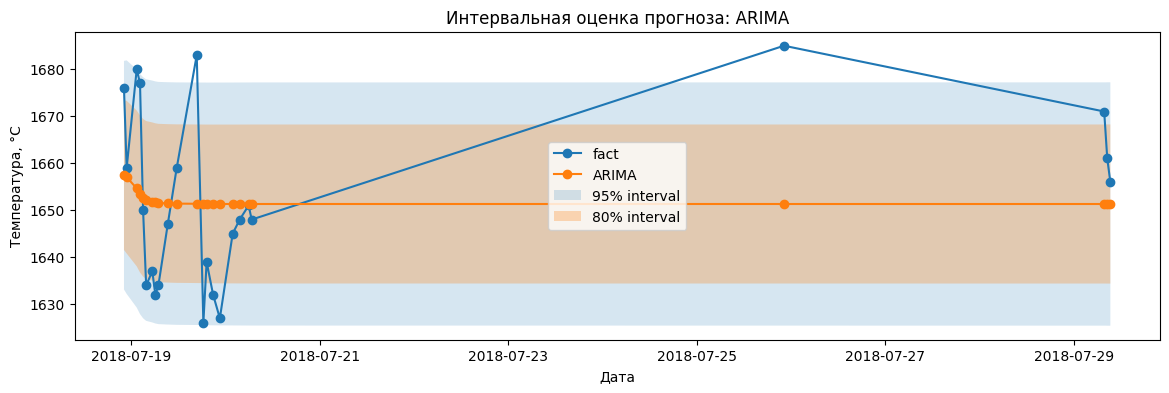

In [47]:
last_interval = cv_df[cv_df['cutoff'] == cv_df['cutoff'].max()].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(last_interval['target_time'], last_interval['y'], marker='o', label='fact')
ax.plot(last_interval['target_time'], last_interval[best_model], marker='o', label=best_model)

for level, alpha in [(95, 0.18), (80, 0.28)]:
    lo_col = f'{best_model}-lo-{level}'
    hi_col = f'{best_model}-hi-{level}'
    if lo_col in last_interval.columns and hi_col in last_interval.columns:
        ax.fill_between(last_interval['target_time'], last_interval[lo_col], last_interval[hi_col], alpha=alpha, label=f'{level}% interval')

ax.set_title(f'Интервальная оценка прогноза: {best_model}')
ax.set_xlabel('Дата')
ax.set_ylabel('Температура, °C')
ax.legend()
plt.show()


Для модели *ARIMA* были рассчитаны прогнозные интервалы 80% и 95%.

Фактическое покрытие оказалось ниже заявленного:

- для 80%-го интервала покрытие составило **62.5%**;
- для 95%-го интервала покрытие составило **84.7%**.

Это означает, что интервалы модели получились слишком узкими: фактические значения температуры выходят за границы интервалов чаще, чем ожидалось.

Средняя ширина интервалов:

- 80%-й интервал: около **33.3 °C**;
- 95%-й интервал: около **51.0 °C**.

По графику видно, что точечный прогноз ARIMA почти горизонтальный и находится около среднего уровня температуры. При этом фактическая температура отдельных плавок заметно колеблется: часть значений выходит даже за 95%-й прогнозный интервал, особенно при резких скачках вверх или вниз.

Следовательно, ARIMA неплохо описывает средний уровень ряда, но недооценивает неопределенность отдельных плавок.  

Вывод: прогнозные интервалы ARIMA слишком оптимистичны: они уже, чем нужно, и покрывают меньше фактических значений, чем заявлено.

### Выводы по задаче №2

1. Для статистического прогнозирования конечной температуры использованы статистические модели: ARIMA, AutoARIMA, ETS, AutoETS, Theta, AutoTheta и Prophet. Для ARIMA/ETS/Theta применяется statsforecast, а Prophet считается отдельным блоком через пакет prophet.
2. Ряд приведен к регулярной шкале sf_ds, где один шаг соответствует следующей плавке. Это сделано потому, что реальные календарные интервалы между плавками нерегулярны. Реальное время target_time сохранено для графиков и интерпретации.
3. Диагностика стационарности дала смешанный результат для исходного ряда: ADF указывает на стационарность (**p-value =  7,8 × 10⁻¹⁹**), а KPSS отвергает стационарность (**p-value = 0.01**). После первого дифференцирования оба теста согласуются, поэтому использование ARIMA с d = 1 является обоснованным.
4. Графики ACF/PACF показывают положительную зависимость на первых лагах и быстрое затухание частной автокорреляции. Это подтверждает, что в ряду есть краткосрочная память соседних плавок, которую хорошо описывает ARIMA-подход.
5. В backtesting лучшей моделью стала ручная ARIMA(2,1,2): MAE = 13.86 °C, RMSE = 16.76 °C. AutoARIMA дала практически такой же результат: MAE = 13.87 °C, RMSE = 16.74 °C.
6. Лучший Prophet-вариант после автоподбора (Prophet_auto_best) показал MAE = 14.23 °C, RMSE = 17.21 °C. Он улучшил ручную Prophet-конфигурацию (MAE = 14.45 °C) и оказался лучше ETS/Theta, но уступил ARIMA.
7. ETS и Theta дали близкие результаты: MAE примерно 14.45-14.47 °C. AutoETS фактически совпал с ETS_manual_ANN, что согласуется с EDA: выраженной сезонности и устойчивого тренда в ряду конечной температуры не обнаружено.
8. Прогноз на следующий горизонт по лучшей модели ARIMA показывает стабильный уровень около 1651-1654 °C. Модель стремится к среднему рабочему уровню ряда и не прогнозирует резкие скачки отдельных плавок.
9. Диагностика остатков ARIMA выглядит приемлемо: ошибки колеблются вокруг нуля, распределение остатков близко к симметричному, тест Jarque-Bera не отвергает нормальность (p-value = 0.43). Тест Ljung-Box на лагах 1, 5, 10 и 24 также не выявил значимой автокорреляции (p-value > 0.05).
10. Прогнозные интервалы ARIMA оказались слишком узкими: 80%-й интервал покрыл только 62.5% фактических значений, а 95%-й интервал - 84.7%. Средняя ширина интервалов составила 33.34 °C и 50.98 °C соответственно. Следовательно, интервалы предсказания требуют дополнительной калибровки.
11. Итоговый статистический benchmark для следующих этапов: MAE ≈ 13.9 °C по лучшей ARIMA-модели. ML/DL модели в задаче №3 должны показать качество лучше этого уровня или хотя бы сопоставимое с ним.
12. Главный вывод: статистические модели хорошо описывают средний уровень конечной температуры, но не всегда улавливают резкие отклонения отдельных плавок. Для повышения точности прогноза конкретной плавки нужно использовать технологические признаки из расширенной таблицы eaf_temperature_heat_level_features.csv.


## Задача №3. ML и DL методы прогнозирования

Раздел будет реализован на следующем этапе. Для него будет использоваться таблица `eaf_temperature_heat_level_features.csv`, где уже собраны температурные, технологические и лаговые признаки по плавкам.

План:

1. Сформировать хронологическое train/validation/test разбиение.
2. Собрать preprocessing-пайплайн для пропусков, флагов наличия измерений и числовых признаков.
3. Сравнить не менее 3 ML моделей.
4. Сравнить не менее 3 DL/нейросетевых подходов, если они доступны в среде.
5. Сравнить ML/DL результаты со статистическим benchmark из задачи №2.


## Задача №4. Пайплайн и отчет исследования

Раздел будет реализован после выбора моделей. В нем нужно будет собрать единый воспроизводимый пайплайн: загрузка данных, подготовка признаков, обучение, backtesting, расчет метрик, диагностика и сохранение результатов.

План:

1. Зафиксировать финальный набор признаков и схему обработки пропусков.
2. Собрать пайплайн обучения и оценки модели.
3. Проверить производительность пайплайна и устойчивость результатов.
4. Подготовить итоговый отчет с численными результатами по задачам №1-№4.
